In [ ]:
# Phase 1
# Importing required libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [ ]:
# Configuration
RAW_PATH = "/content/fertilizer_recommendation_dataset.csv"   # file Path
PROCESSED_DIR = "data/processed"
PROCESSED_PATH = os.path.join(PROCESSED_DIR, "f2_cleaned.csv")
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [ ]:
# 1. Loading the dataset
import pandas as pd

# Load the raw dataset
df = pd.read_csv(RAW_PATH)

print("Loaded dataset from:", RAW_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
print(df.head())


Loaded dataset from: /content/fertilizer_recommendation_dataset.csv
Shape: (3100, 12)
Columns: ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Soil', 'Crop', 'Fertilizer', 'Remark']

   Temperature  Moisture    Rainfall        PH   Nitrogen  Phosphorous  \
0    50.179845  0.725893  205.600816  6.227358  66.701872    76.963560   
1    21.633318  0.721958  306.081601  7.173131  71.583316   163.057636   
2    23.060964  0.685751  259.336414  7.380793  75.709830    62.091508   
3    26.241975  0.755095  212.703513  6.883367  78.033687   151.012521   
4    21.490157  0.730672  268.786767  7.578760  71.765123    66.257371   

    Potassium    Carbon        Soil  Crop                  Fertilizer  \
0   96.429065  0.496300  Loamy Soil  rice                     Compost   
1  148.128347  1.234242  Loamy Soil  rice     Balanced NPK Fertilizer   
2   80.308971  1.795650  Peaty Soil  rice  Water Retaining Fertilizer   
3  153.005712  1.517556  Loamy 

In [ ]:
# 2. Quick Overview

print("Columns and Data Types:")
print(df.dtypes)
print()

print("Basic Info:")
print(df.info())
print()

print("Summary Statistics (numerical features):")
print(df.describe())
print()

print("First 5 rows:")
print(df.head())
print()


Columns and Data Types:
Temperature    float64
Moisture       float64
Rainfall       float64
PH             float64
Nitrogen       float64
Phosphorous    float64
Potassium      float64
Carbon         float64
Soil            object
Crop            object
Fertilizer      object
Remark          object
dtype: object

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
 11  Remark       31

In [ ]:
# 3. Looking for Missing Values and Uniqueness

print("Missing Values per Column:")
print(df.isna().sum())
print()

print("Unique Value Counts per Column:")
print(df.nunique())
print()

# % of missing values (if any)
missing_percent = (df.isna().sum() / len(df)) * 100
print("Missing Value Percentage per Column:")
print(missing_percent[missing_percent > 0])
print()



Missing Values per Column:
Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64

Unique Value Counts per Column:
Temperature    2947
Moisture       2960
Rainfall       2950
PH             2961
Nitrogen       2947
Phosphorous    2948
Potassium      2945
Carbon         2940
Soil              5
Crop             31
Fertilizer       10
Remark           10
dtype: int64

Missing Value Percentage per Column:
Series([], dtype: float64)



In [ ]:
# 4. Basic Statistics
import numpy as np

print("Numeric Summary:")
print(df.describe(include=[np.number]).T)
print()

print("Categorical Summary (Top 10 values per column):")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f"\nColumn: {col}")
        print(df[col].value_counts(dropna=False).head(10))
else:
    print("No categorical columns found.")


Numeric Summary:
              count        mean        std        min        25%        50%  \
Temperature  3100.0   27.271096   9.114450   4.011486  22.408505  26.132938   
Moisture     3100.0    0.600763   0.144947   0.227436   0.493595   0.599520   
Rainfall     3100.0  111.024949  77.151880 -85.709593  61.283985  96.485935   
PH           3100.0    6.379775   0.957103   3.448974   5.860489   6.337308   
Nitrogen     3100.0   61.278480  10.186410  35.527718  54.835715  59.429649   
Phosphorous  3100.0   69.582850  42.226712 -37.649739  43.039260  58.205269   
Potassium    3100.0   69.721167  35.304241 -20.509108  49.992405  58.710808   
Carbon       3100.0    1.474325   0.698300  -0.280560   0.956401   1.463357   

                    75%         max  
Temperature   29.987887   56.653592  
Moisture       0.708575    0.972361  
Rainfall     147.619401  411.955947  
PH             6.899739    9.562341  
Nitrogen      65.792790   98.581039  
Phosphorous   86.108983  177.314481  
Potas

In [ ]:
# 5. Cleaning column names
df = df.rename(columns=lambda x: x.strip().replace(' ', '_'))

# Expected columns in the fertilizer dataset
expected_cols = [
    'Temperature', 'Moisture', 'Rainfall', 'PH',
    'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon',
    'Soil', 'Crop', 'Fertilizer', 'Remark'
]

missing_expected = [c for c in expected_cols if c not in df.columns]
if missing_expected:
    print("Warning: expected columns missing:", missing_expected)
    print("Current columns:", df.columns.tolist())
else:
    print("All expected columns present.")



All expected columns present.


In [ ]:
# 6. Quick Cleaning

# Columns that should be numeric
numeric_candidates = [
    'Temperature', 'Moisture', 'Rainfall', 'PH',
    'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon'
]

# Convert numeric-like strings to floats
for col in numeric_candidates:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '', regex=True).astype(float)

# Trim whitespace from text columns
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].astype(str).str.strip()


In [ ]:
# 7. Handling missing values (simple, adjustable)

# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Fill numeric NaNs with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical NaNs with 'Unknown'
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("After simple imputation, missing counts:")
print(df.isna().sum())



After simple imputation, missing counts:
Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64


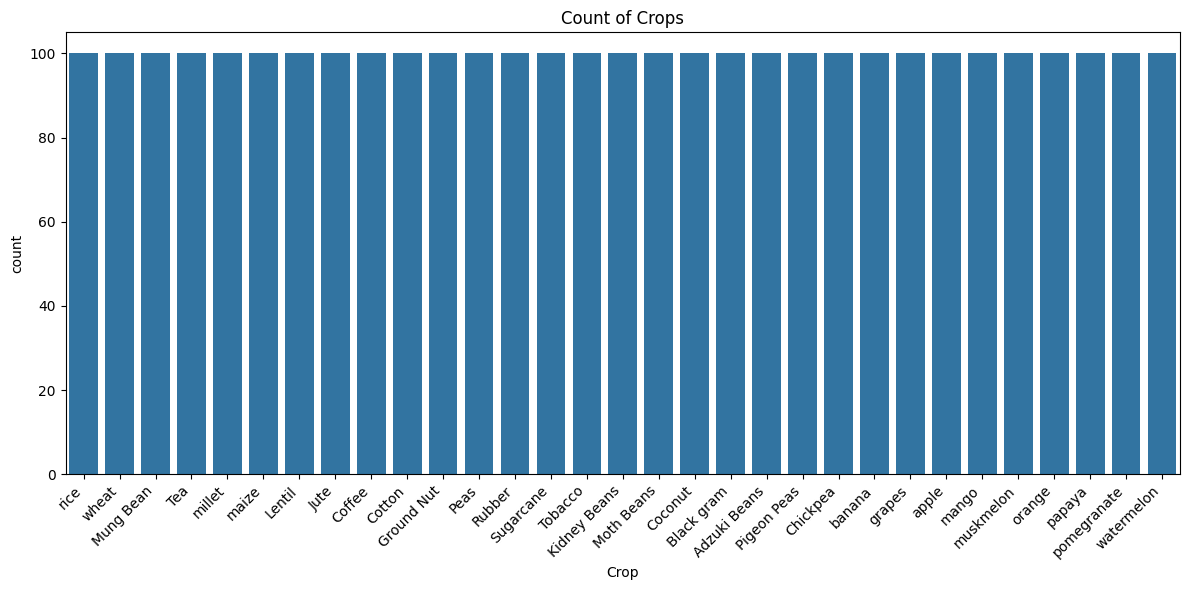

Crop count plot saved at: data/processed/count_crop.png


In [ ]:
# 8. Quick EDA plots
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Crop', order=df['Crop'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title("Count of Crops")
plt.tight_layout()

output_path = os.path.join(PROCESSED_DIR, "count_crop.png")
plt.savefig(output_path)
plt.show()
plt.close()

print(f"Crop count plot saved at: {output_path}")



<Figure size 1200x800 with 0 Axes>

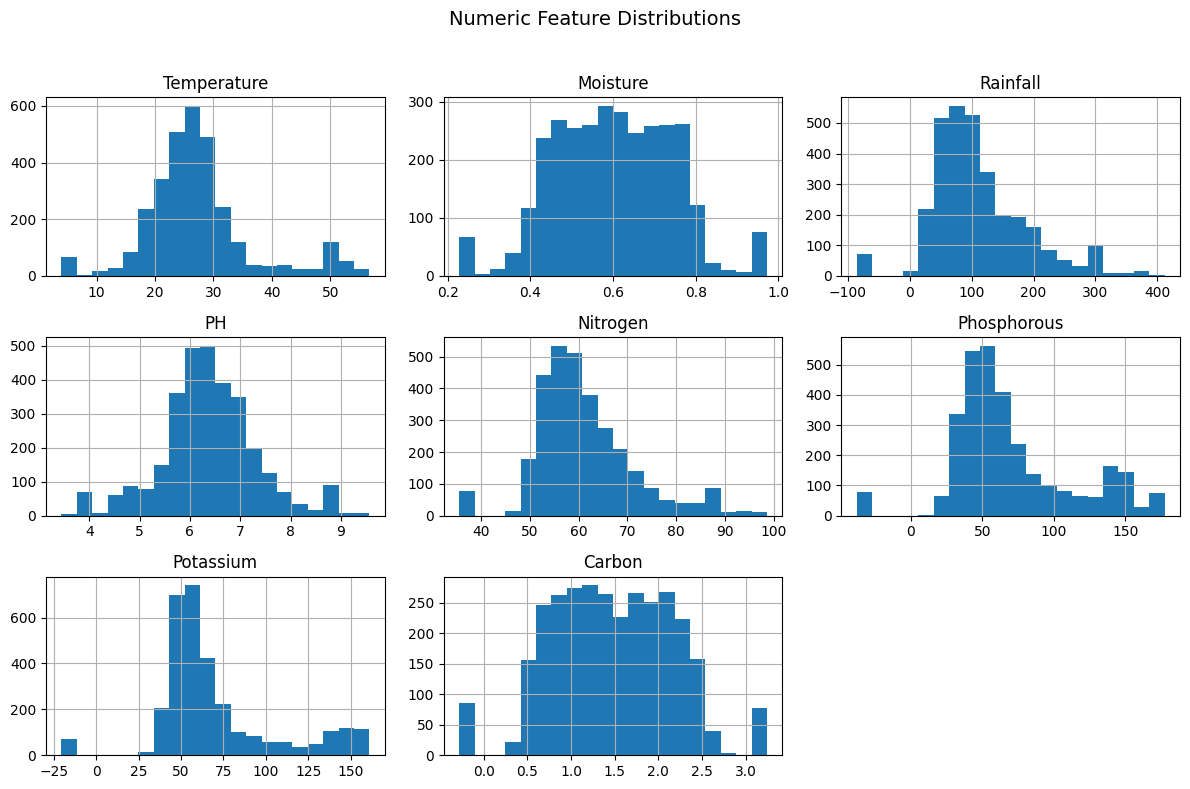

Numeric distributions plot saved at: data/processed/numeric_distributions.png


In [ ]:
# 9. Numeric Histograms
plt.figure(figsize=(12,8))
df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Numeric Feature Distributions", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.96])

output_path = os.path.join(PROCESSED_DIR, "numeric_distributions.png")
plt.savefig(output_path)
plt.show()
plt.close()

print(f"Numeric distributions plot saved at: {output_path}")


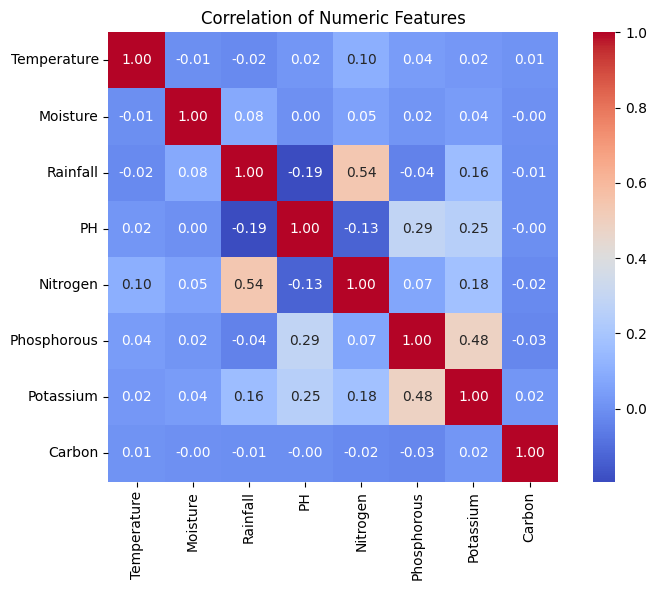

Correlation heatmap saved at: data/processed/numeric_correlation.png
All quick EDA plots saved in: data/processed


In [ ]:
# 10. Correlation Heatmap of Numeric Features
plt.figure(figsize=(8,6))
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation of Numeric Features")
plt.tight_layout()

output_path = os.path.join(PROCESSED_DIR, "numeric_correlation.png")
plt.savefig(output_path)
plt.show()
plt.close()

print(f"Correlation heatmap saved at: {output_path}")
print(f"All quick EDA plots saved in: {PROCESSED_DIR}")


In [ ]:
# 9. Quick Class Balance Check
print("\nTarget distribution (Fertilizer):")
print(df['Fertilizer'].value_counts())
print("\nTarget distribution (Fertilizer) - Normalized:")
print(df['Fertilizer'].value_counts(normalize=True).round(3))



Target distribution (Fertilizer):
Fertilizer
DAP                           1054
Water Retaining Fertilizer     675
Compost                        375
Muriate of Potash              326
Lime                           181
Balanced NPK Fertilizer        157
Urea                           154
Organic Fertilizer              95
Gypsum                          52
General Purpose Fertilizer      31
Name: count, dtype: int64

Target distribution (Fertilizer) - Normalized:
Fertilizer
DAP                           0.340
Water Retaining Fertilizer    0.218
Compost                       0.121
Muriate of Potash             0.105
Lime                          0.058
Balanced NPK Fertilizer       0.051
Urea                          0.050
Organic Fertilizer            0.031
Gypsum                        0.017
General Purpose Fertilizer    0.010
Name: proportion, dtype: float64


In [ ]:
# 11. Saving Cleaned Dataset
df.to_csv(PROCESSED_PATH, index=False)
print(f"Cleaned dataset saved to: {PROCESSED_PATH}")
print("Final shape:", df.shape)



Cleaned dataset saved to: data/processed/f2_cleaned.csv
Final shape: (3100, 12)


In [ ]:
# Phase 2: Weather Data Enrichment
import requests
from datetime import datetime, timezone
import pandas as pd
import os

API_KEY = "e59abe52d755146997dd0d388e107010"
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

def get_weather(lat, lon):
    """Fetch current weather for a given lat/lon using OpenWeatherMap API."""
    url = f"{BASE_URL}?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
    response = requests.get(url)
    j = response.json()

    if response.status_code != 200 or "main" not in j:
        print("API error:", j)
        return None

    rain = j.get('rain', {}).get('1h', 0)  # safely extract rain if available

    return {
        "lat": lat,
        "lon": lon,
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "temp_c": j['main']['temp'],
        "humidity": j['main']['humidity'],
        "rain_mm_1h": rain,
        "pressure": j['main'].get('pressure', None),   # optional
        "wind_speed": j.get('wind', {}).get('speed', None)  # optional
    }

# Regions to fetch weather
regions = [
    {"name": "Delhi", "lat": 28.6139, "lon": 77.2090},
    {"name": "Mumbai", "lat": 19.0760, "lon": 72.8777},
    {"name": "Chennai", "lat": 13.0827, "lon": 80.2707},
    {"name": "Kolkata", "lat": 22.5726, "lon": 88.3639},
    {"name": "Bengaluru", "lat": 12.9716, "lon": 77.5946},
    {"name": "Hyderabad", "lat": 17.3850, "lon": 78.4867},
    {"name": "Lucknow", "lat": 26.8467, "lon": 80.9462},
    {"name": "Jaipur", "lat": 26.9124, "lon": 75.7873},
    {"name": "Patna", "lat": 25.5941, "lon": 85.1376},
    {"name": "Bhopal", "lat": 23.2599, "lon": 77.4126},
    {"name": "Ahmedabad", "lat": 23.0225, "lon": 72.5714},
    {"name": "Raipur", "lat": 21.2514, "lon": 81.6296},
    {"name": "Ranchi", "lat": 23.3441, "lon": 85.3096},
    {"name": "Guwahati", "lat": 26.1445, "lon": 91.7362}
]

# Collecting weather data
weather_data = []
for reg in regions:
    w = get_weather(reg["lat"], reg["lon"])
    if w:
        w["region"] = reg["name"]
        weather_data.append(w)

# Save to processed folder
PROCESSED_DIR = "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)
WEATHER_PATH = os.path.join(PROCESSED_DIR, "weather_data.csv")

df_weather = pd.DataFrame(weather_data)
df_weather.to_csv(WEATHER_PATH, index=False)

print("Weather data saved with", len(df_weather), "cities")
print(df_weather.head())


Weather data saved with 14 cities
       lat      lon                         timestamp  temp_c  humidity  \
0  28.6139  77.2090  2025-09-02T09:17:35.466994+00:00   27.07        94   
1  19.0760  72.8777  2025-09-02T09:17:35.589051+00:00   29.00        84   
2  13.0827  80.2707  2025-09-02T09:17:35.699679+00:00   32.63        71   
3  22.5726  88.3639  2025-09-02T09:17:35.809088+00:00   28.96        84   
4  12.9716  77.5946  2025-09-02T09:17:35.918597+00:00   26.83        71   

   rain_mm_1h  pressure  wind_speed     region  
0        0.20      1001        2.06      Delhi  
1        0.00      1004        6.69     Mumbai  
2        0.00      1002        6.26    Chennai  
3        3.45       999        6.17    Kolkata  
4        0.00      1008        0.45  Bengaluru  


In [ ]:
import os
import pandas as pd

# Ensure processed folder exists
PROCESSED_DIR = "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save weather data
WEATHER_PATH = os.path.join(PROCESSED_DIR, "weather_data.csv")

df_weather = pd.DataFrame(weather_data)
df_weather.to_csv(WEATHER_PATH, index=False)

print(f"Weather data saved to: {WEATHER_PATH}")
print("Shape:", df_weather.shape)
print(df_weather.head())


Weather data saved to: data/processed/weather_data.csv
Shape: (14, 9)
       lat      lon                         timestamp  temp_c  humidity  \
0  28.6139  77.2090  2025-09-02T09:08:28.430663+00:00   27.07        94   
1  19.0760  72.8777  2025-09-02T09:08:28.547504+00:00   29.00        84   
2  13.0827  80.2707  2025-09-02T09:08:28.658412+00:00   32.63        71   
3  22.5726  88.3639  2025-09-02T09:08:28.778452+00:00   28.96        84   
4  12.9716  77.5946  2025-09-02T09:08:28.895078+00:00   26.47        73   

   rain_mm_1h  pressure  wind_speed     region  
0        0.20      1001        2.06      Delhi  
1        0.00      1005        6.69     Mumbai  
2        0.00      1002        6.26    Chennai  
3        2.59       999        6.17    Kolkata  
4        0.00      1008        0.89  Bengaluru  


In [ ]:
import pandas as pd
import numpy as np
import os

# Paths
CROP_PATH = "/content/fertilizer_recommendation_dataset.csv"
WEATHER_PATH = "/content/data/processed/weather_data.csv"
OUTPUT_DIR = "data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)
MERGED_PATH = os.path.join(OUTPUT_DIR, "merged_crop_weather.csv")

# Loading datasets
crop_df = pd.read_csv(CROP_PATH)
weather_df = pd.read_csv(WEATHER_PATH)

print("Crop dataset columns:", crop_df.columns.tolist())
print("Weather dataset columns:", weather_df.columns.tolist())

# Merging on region if available
if "Region" in crop_df.columns and "region" in weather_df.columns:
    merged_df = pd.merge(crop_df, weather_df, left_on="Region", right_on="region", how="left")
else:
    # No region info → assign random weather rows
    weather_rows = weather_df.sample(n=len(crop_df), replace=True, random_state=42).reset_index(drop=True)
    merged_df = pd.concat([crop_df.reset_index(drop=True), weather_rows.drop(columns=["lat", "lon"])], axis=1)

# Saving merged dataset
merged_df.to_csv(MERGED_PATH, index=False)

print(f"Merged dataset saved as: {MERGED_PATH}")
print("Shape:", merged_df.shape)
print(merged_df.head())


Crop dataset columns: ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Soil', 'Crop', 'Fertilizer', 'Remark']
Weather dataset columns: ['lat', 'lon', 'timestamp', 'temp_c', 'humidity', 'rain_mm_1h', 'pressure', 'wind_speed', 'region']
Merged dataset saved as: data/processed/merged_crop_weather.csv
Shape: (3100, 19)
   Temperature  Moisture    Rainfall        PH   Nitrogen  Phosphorous  \
0    50.179845  0.725893  205.600816  6.227358  66.701872    76.963560   
1    21.633318  0.721958  306.081601  7.173131  71.583316   163.057636   
2    23.060964  0.685751  259.336414  7.380793  75.709830    62.091508   
3    26.241975  0.755095  212.703513  6.883367  78.033687   151.012521   
4    21.490157  0.730672  268.786767  7.578760  71.765123    66.257371   

    Potassium    Carbon        Soil  Crop                  Fertilizer  \
0   96.429065  0.496300  Loamy Soil  rice                     Compost   
1  148.128347  1.234242  Loamy Soil  rice   

In [ ]:
#Importing libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [ ]:
merged_df = pd.read_csv("/content/data/processed/merged_crop_weather.csv")
print("Shape:", merged_df.shape)
print(merged_df.head())

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Loading merged dataset
df = pd.read_csv("/content/data/processed/merged_crop_weather.csv")

# 1. Summary
print(df.info())
print(df.describe())

# 2. Checking missing values
print("Missing values:\n", df.isnull().sum())


Shape: (3100, 19)
   Temperature  Moisture    Rainfall        PH   Nitrogen  Phosphorous  \
0    50.179845  0.725893  205.600816  6.227358  66.701872    76.963560   
1    21.633318  0.721958  306.081601  7.173131  71.583316   163.057636   
2    23.060964  0.685751  259.336414  7.380793  75.709830    62.091508   
3    26.241975  0.755095  212.703513  6.883367  78.033687   151.012521   
4    21.490157  0.730672  268.786767  7.578760  71.765123    66.257371   

    Potassium    Carbon        Soil  Crop                  Fertilizer  \
0   96.429065  0.496300  Loamy Soil  rice                     Compost   
1  148.128347  1.234242  Loamy Soil  rice     Balanced NPK Fertilizer   
2   80.308971  1.795650  Peaty Soil  rice  Water Retaining Fertilizer   
3  153.005712  1.517556  Loamy Soil  rice     Balanced NPK Fertilizer   
4   97.000886  1.782985  Peaty Soil  rice          Organic Fertilizer   

                                              Remark  \
0  Enhances organic matter and improves so

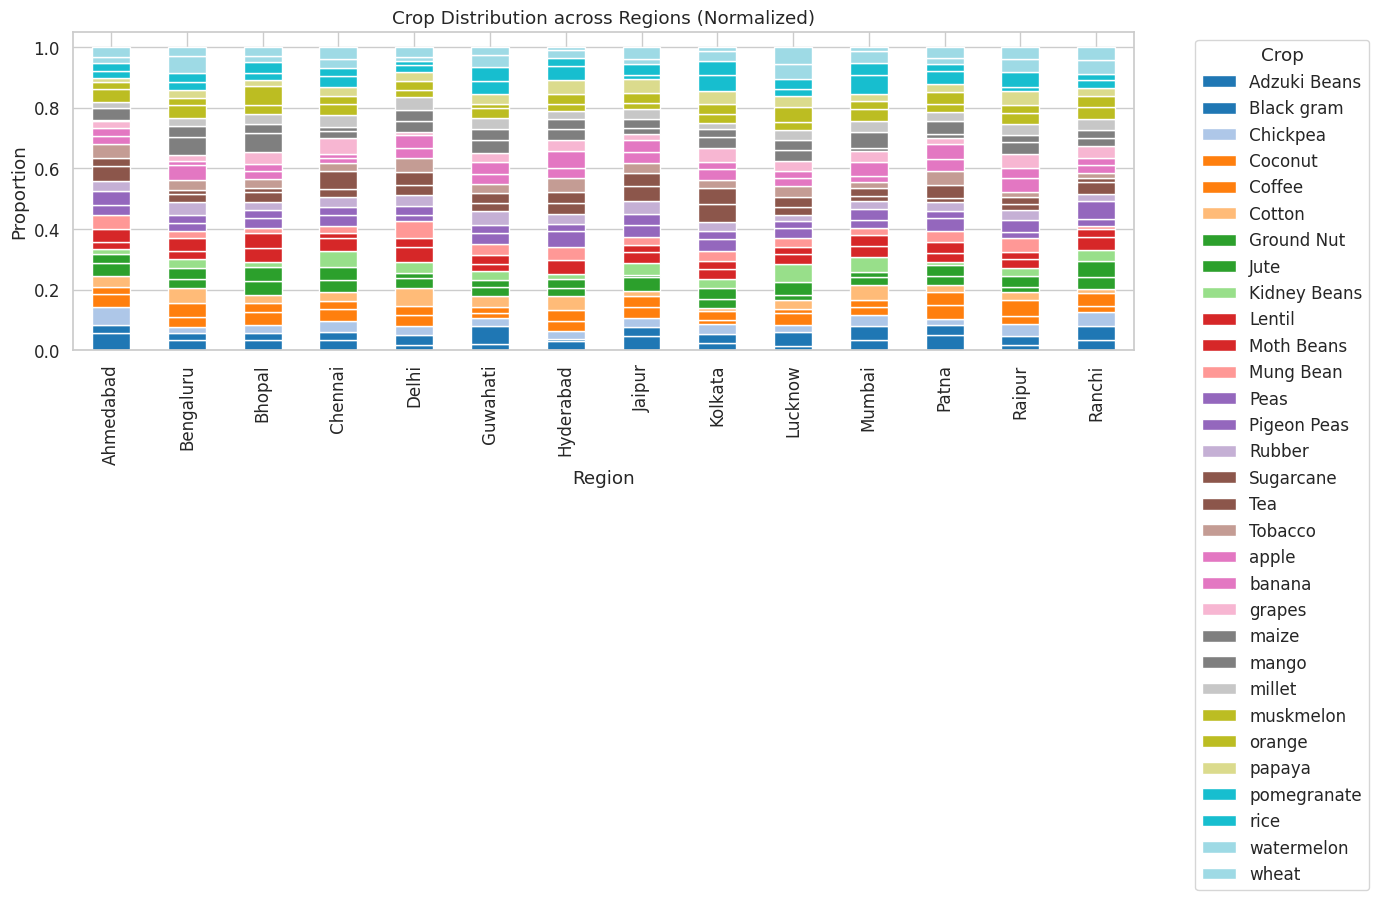

In [ ]:
# 3. Crop Types across Regions

# Ensuring correct column names
if "region" in df.columns and "Crop" in df.columns:
    # Step 1: Pivot table (counts of crops per region)
    pivot = df.pivot_table(index="region", columns="Crop", aggfunc="size", fill_value=0)

    # Step 2: Normalizing rows (so each region sums to 1)
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

    # Step 3: Plotting stacked bar
    pivot_norm.plot(kind="bar", stacked=True, figsize=(14,7), colormap="tab20")
    plt.title("Crop Distribution across Regions (Normalized)")
    plt.ylabel("Proportion")
    plt.xlabel("Region")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Crop")
    plt.tight_layout()
    plt.savefig("eda_crop_region_stacked.png")
    plt.show()
else:
    print("Columns 'region' and 'Crop' not found in the dataset.")





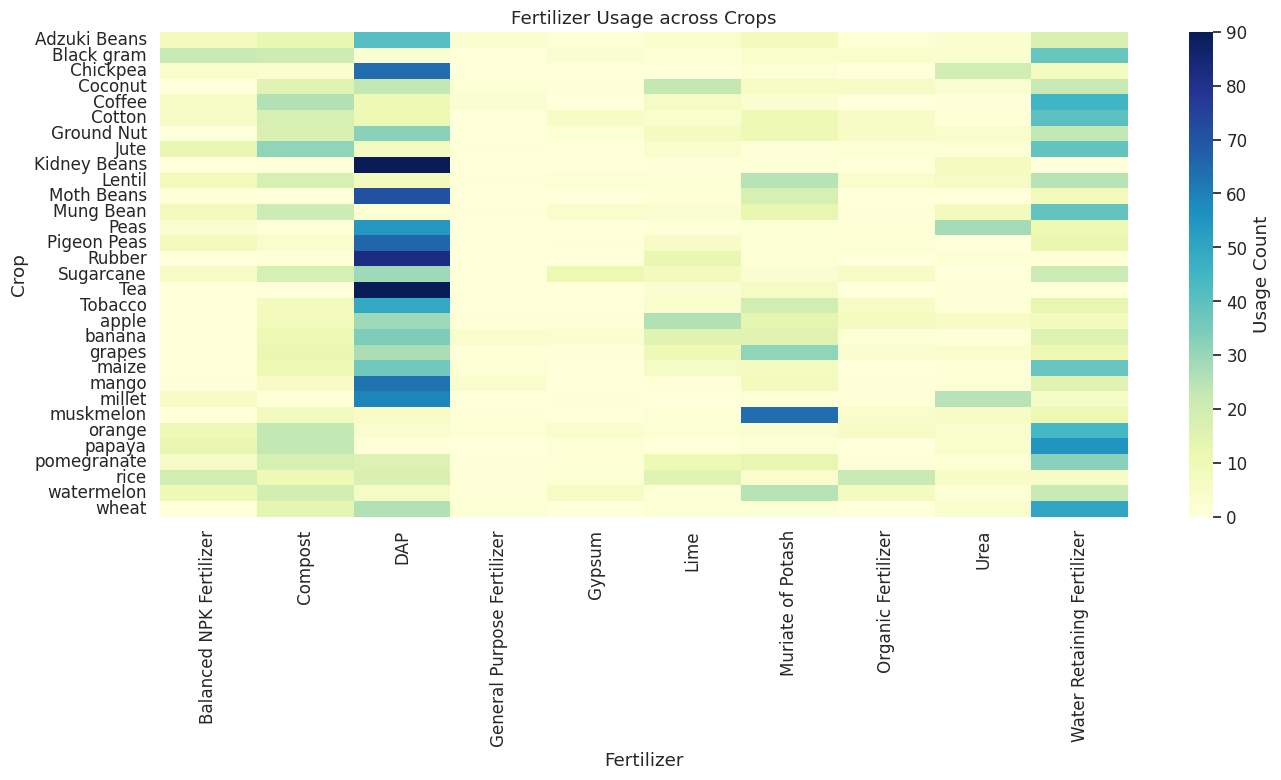

In [ ]:
# 4. Fertilizer usage across Crops (Heatmap)

# Ensuring correct column names
if "Crop" in df.columns and "Fertilizer" in df.columns:
    # Pivot table: crops vs fertilizer counts
    fert_pivot = df.pivot_table(index="Crop", columns="Fertilizer", aggfunc="size", fill_value=0)

    # Plottting heatmap
    plt.figure(figsize=(14,8))
    sns.heatmap(fert_pivot, cmap="YlGnBu", annot=False, cbar_kws={'label': 'Usage Count'})
    plt.title("Fertilizer Usage across Crops")
    plt.ylabel("Crop")
    plt.xlabel("Fertilizer")
    plt.tight_layout()
    plt.savefig("eda_fertilizer_crop_heatmap.png")
    plt.show()
else:
    print("Columns 'Crop' and 'Fertilizer' not found in the dataset.")


/tmp/ipython-input-331797708.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


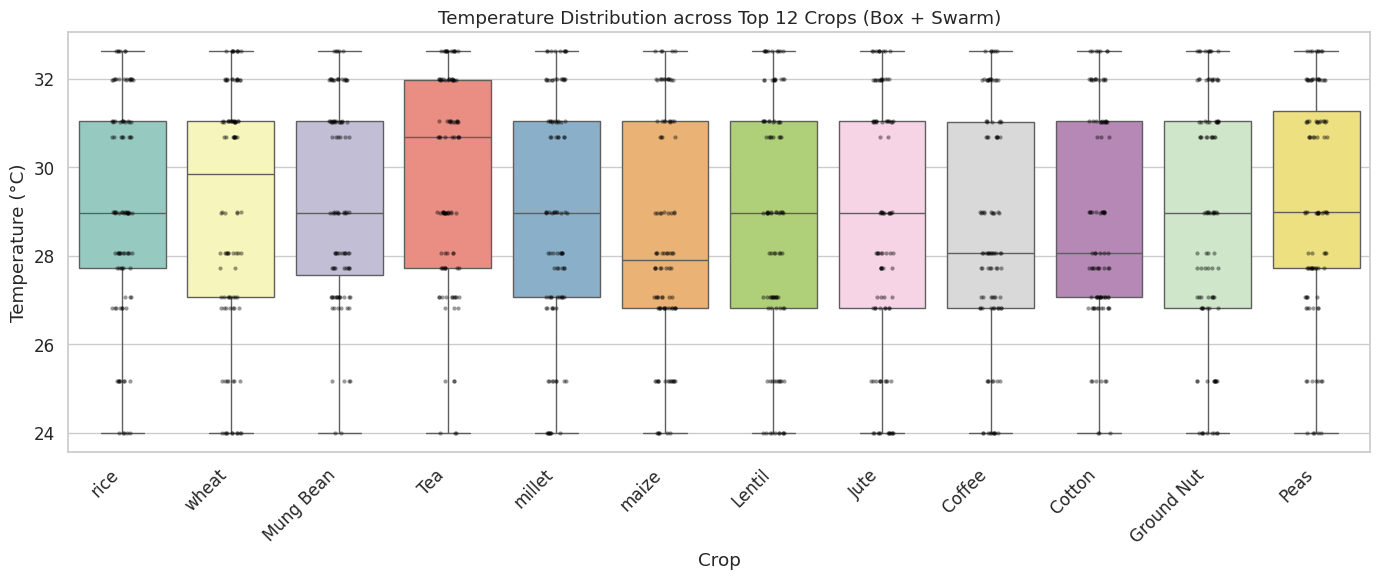

In [ ]:
# Temperature distribution across top 12 crops (Box + Swarmplot)

import matplotlib.pyplot as plt
import seaborn as sns

# Selecting top 12 crops by frequency
top_n = 12
top_crops = df['Crop'].value_counts().nlargest(top_n).index

df_temp = df[df['Crop'].isin(top_crops)].copy()
plt.figure(figsize=(14,6))

# Boxplot → showing median, quartiles, and spread of temperature
sns.boxplot(
    x="Crop",
    y="temp_c",
    data=df_temp,
    showfliers=False,   # remove extreme outlier dots
    palette="Set3"
)

# Swarmplot → showing individual data points (clarity on distribution)
sns.stripplot(
    x="Crop",
    y="temp_c",
    data=df_temp,
    color="black",
    size=3,
    alpha=0.4
)


# Rotating crop names for readability
plt.xticks(rotation=45, ha="right")

# Labels and title
plt.title("Temperature Distribution across Top 12 Crops (Box + Swarm)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Crop")

# Adjusting layout and saving
plt.tight_layout()
plt.savefig("eda_temp_crop_swarm.png")
plt.show()



/tmp/ipython-input-114655450.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


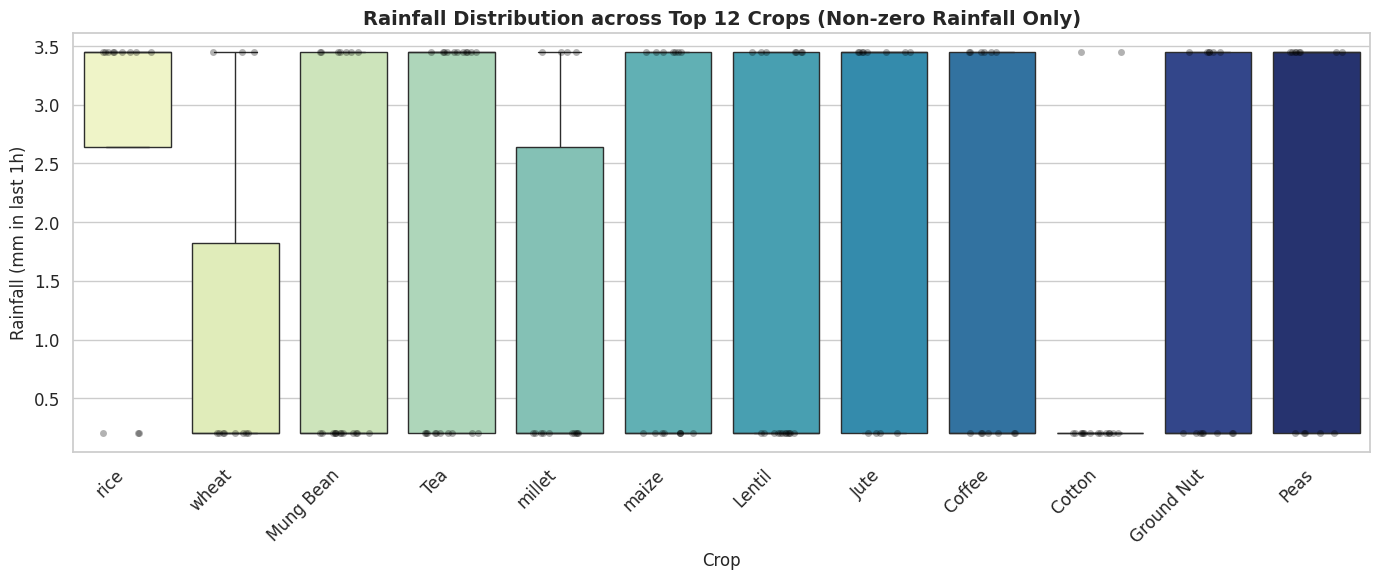

In [ ]:
df_rain_nonzero = df_rain[df_rain["rain_mm_1h"] > 0]

plt.figure(figsize=(14,6))
sns.boxplot(
    x="Crop",
    y="rain_mm_1h",
    data=df_rain_nonzero,
    palette="YlGnBu",
    showfliers=False
)
sns.stripplot(
    x="Crop",
    y="rain_mm_1h",
    data=df_rain_nonzero,
    color="black",
    alpha=0.3,
    jitter=0.25
)

plt.xticks(rotation=45, ha="right")
plt.title("Rainfall Distribution across Top 12 Crops (Non-zero Rainfall Only)", fontsize=14, weight="bold")
plt.xlabel("Crop", fontsize=12)
plt.ylabel("Rainfall (mm in last 1h)", fontsize=12)
plt.tight_layout()
plt.show()



In [ ]:
# Importing the libraries for performing Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Setting target column
target_col = "Crop"

df_enc = df.copy()
feature_encoders = {}

# Encoding categorical features except target
for col in df_enc.drop(target_col, axis=1).select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    feature_encoders[col] = le

# Encoding target
target_encoder = LabelEncoder()
df_enc[target_col] = target_encoder.fit_transform(df_enc[target_col])

print("Encoded dataframe shape:", df_enc.shape)
print(df_enc.head())
print("\nTarget classes:", list(target_encoder.classes_))


Encoded dataframe shape: (3100, 19)
   Temperature  Moisture    Rainfall        PH   Nitrogen  Phosphorous  \
0    50.179845  0.725893  205.600816  6.227358  66.701872    76.963560   
1    21.633318  0.721958  306.081601  7.173131  71.583316   163.057636   
2    23.060964  0.685751  259.336414  7.380793  75.709830    62.091508   
3    26.241975  0.755095  212.703513  6.883367  78.033687   151.012521   
4    21.490157  0.730672  268.786767  7.578760  71.765123    66.257371   

    Potassium    Carbon  Soil  Crop  Fertilizer  Remark  timestamp  temp_c  \
0   96.429065  0.496300     2    28           1       2          6   31.05   
1  148.128347  1.234242     2    28           0       6          3   28.96   
2   80.308971  1.795650     4    28           9       4         12   23.99   
3  153.005712  1.517556     2    28           0       6         10   31.02   
4   97.000886  1.782985     4    28           7       1          7   30.68   

   humidity  rain_mm_1h  pressure  wind_speed  reg

In [ ]:
target_col = "Crop"   # change this if target column has a different name

X = df_enc.drop(target_col, axis=1)
y = df_enc[target_col]



In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Shapes:
X_train: (2480, 18)
X_test: (620, 18)
y_train: (2480,)
y_test: (620,)


Test Accuracy: 0.5952

Classification Report:
              precision    recall  f1-score   support

Adzuki Beans       0.71      1.00      0.83        20
  Black gram       0.77      0.85      0.81        20
    Chickpea       0.83      0.75      0.79        20
     Coconut       0.73      0.80      0.76        20
      Coffee       0.47      0.45      0.46        20
      Cotton       0.36      0.45      0.40        20
  Ground Nut       0.44      0.75      0.56        20
        Jute       0.62      0.75      0.68        20
Kidney Beans       0.51      0.90      0.65        20
      Lentil       0.56      0.45      0.50        20
  Moth Beans       0.60      0.75      0.67        20
   Mung Bean       0.53      0.50      0.51        20
        Peas       0.69      0.90      0.78        20
 Pigeon Peas       0.54      0.35      0.42        20
      Rubber       0.73      0.80      0.76        20
   Sugarcane       0.54      0.35      0.42        20
         Tea       0.84      0.80  

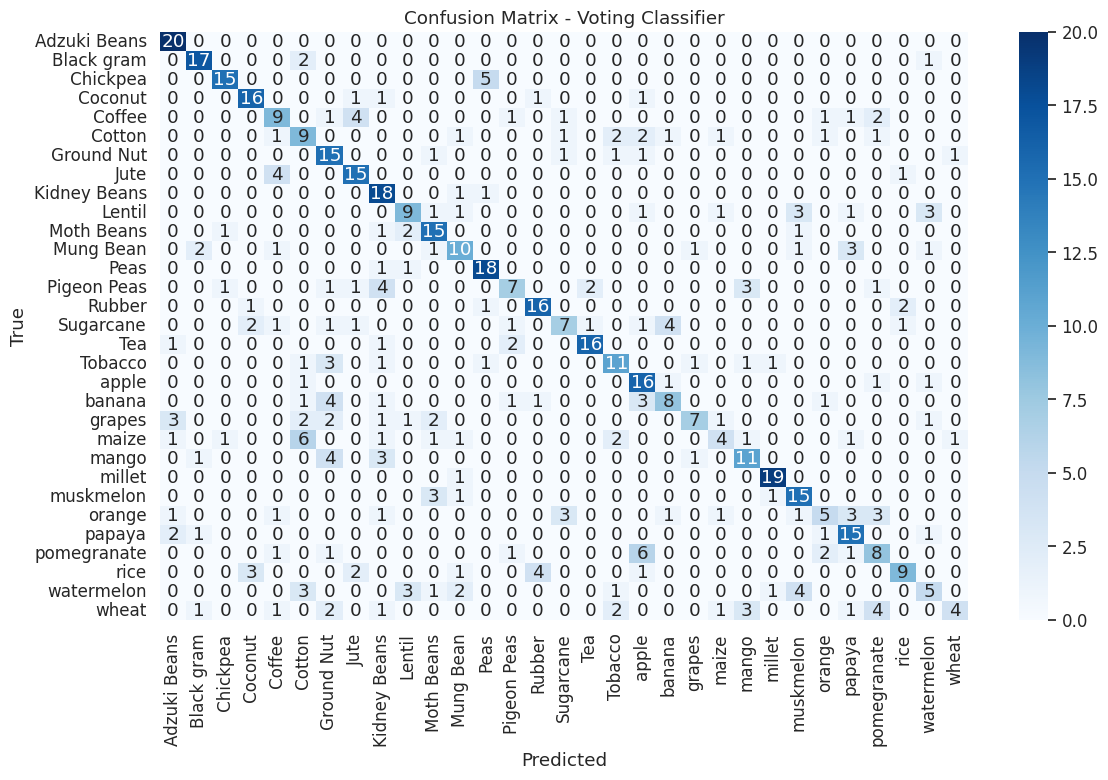

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Defining models
log_clf = LogisticRegression(
    max_iter=5000,
    solver="saga",
    tol=0.01
)
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
gb_clf = GradientBoostingClassifier(random_state=42)

# 2. Voting Classifier (ensemble)
voting_clf = VotingClassifier(
    estimators=[("lr", log_clf), ("rf", rf_clf), ("gb", gb_clf)],
    voting="hard"
)

# 3. Train
voting_clf.fit(X_train, y_train)

# 4. Predict
y_pred = voting_clf.predict(X_test)

# 5. Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Voting Classifier")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_encoder.classes_))


Accuracy: 0.5951612903225807

Classification Report:
               precision    recall  f1-score   support

Adzuki Beans       0.71      1.00      0.83        20
  Black gram       0.77      0.85      0.81        20
    Chickpea       0.83      0.75      0.79        20
     Coconut       0.73      0.80      0.76        20
      Coffee       0.47      0.45      0.46        20
      Cotton       0.36      0.45      0.40        20
  Ground Nut       0.44      0.75      0.56        20
        Jute       0.62      0.75      0.68        20
Kidney Beans       0.51      0.90      0.65        20
      Lentil       0.56      0.45      0.50        20
  Moth Beans       0.60      0.75      0.67        20
   Mung Bean       0.53      0.50      0.51        20
        Peas       0.69      0.90      0.78        20
 Pigeon Peas       0.54      0.35      0.42        20
      Rubber       0.73      0.80      0.76        20
   Sugarcane       0.54      0.35      0.42        20
         Tea       0.84    

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

# XGBoost model (with silent mode)
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0   # <- suppress training logs
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nXGBoost Report:\n", classification_report(y_test, y_pred_xgb, target_names=target_encoder.classes_))

# LightGBM model (also suppress logs)
lgbm_clf = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1   # <- suppress logs
)
lgbm_clf.fit(X_train, y_train)
y_pred_lgbm = lgbm_clf.predict(X_test)

print("\nLightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("\nLightGBM Report:\n", classification_report(y_test, y_pred_lgbm, target_names=target_encoder.classes_))


XGBoost Accuracy: 0.6048387096774194

XGBoost Report:
               precision    recall  f1-score   support

Adzuki Beans       0.86      0.95      0.90        20
  Black gram       0.79      0.75      0.77        20
    Chickpea       0.94      0.75      0.83        20
     Coconut       0.83      0.75      0.79        20
      Coffee       0.47      0.40      0.43        20
      Cotton       0.29      0.30      0.29        20
  Ground Nut       0.40      0.60      0.48        20
        Jute       0.63      0.60      0.62        20
Kidney Beans       0.65      0.75      0.70        20
      Lentil       0.58      0.35      0.44        20
  Moth Beans       0.79      0.75      0.77        20
   Mung Bean       0.50      0.55      0.52        20
        Peas       0.76      0.95      0.84        20
 Pigeon Peas       0.53      0.45      0.49        20
      Rubber       0.78      0.70      0.74        20
   Sugarcane       0.52      0.55      0.54        20
         Tea       0.78   

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Example: Random Forest hyperparameter search
param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    rf_clf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("Best RF Accuracy:", rf_search.best_score_)
print("Best Params:", rf_search.best_params_)


Best RF Accuracy: 0.5891213903633719
Best Params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


In [ ]:
from sklearn.ensemble import StackingClassifier

stack_clf = StackingClassifier(
    estimators=[
        ("rf", rf_clf),
        ("xgb", xgb_clf),
        ("lgbm", lgbm_clf),
        ("gb", gb_clf)
    ],
    final_estimator=LogisticRegression(max_iter=5000),
    n_jobs=-1
)

stack_clf.fit(X_train, y_train)
y_pred_stack = stack_clf.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))


Stacking Accuracy: 0.6064516129032258


In [ ]:
#BIOFERTILIZER RECOMMENDATION SYSTEM

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
feature_encoders = {}

# Defining new target
target_col = "Fertilizer"

# Encoding categorical features (except target)
for col in df_enc.drop(target_col, axis=1).select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    feature_encoders[col] = le

# Encoding target (Fertilizer)
target_encoder = LabelEncoder()
df_enc[target_col] = target_encoder.fit_transform(df_enc[target_col])


In [ ]:
#X = df_enc.drop(["Fertilizer", "Remark"], axis=1)
#y = df_enc["Fertilizer"]
features_to_keep = ["Nitrogen","Phosphorous","Potassium","PH",
                    "Moisture","Rainfall","Temperature","humidity","region"]
X = df_enc[features_to_keep]
y = df_enc["Fertilizer"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Base learners
base_models = [
    ("xgb", XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)),
    ("lgbm", LGBMClassifier(random_state=42)),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("lr", LogisticRegression(max_iter=5000, solver="saga"))
]

# Meta learner (final model)
stack_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=5000),
    cv=5,
    n_jobs=-1
)

# Training
stack_clf.fit(X_train, y_train)

# Predicting
y_pred = stack_clf.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=target_encoder.classes_
))


Accuracy: 0.8629032258064516

Classification Report:
                             precision    recall  f1-score   support

   Balanced NPK Fertilizer       0.71      0.94      0.81        31
                   Compost       0.44      0.05      0.10        75
                       DAP       0.99      0.99      0.99       211
General Purpose Fertilizer       0.75      0.50      0.60         6
                    Gypsum       1.00      0.82      0.90        11
                      Lime       0.95      1.00      0.97        36
         Muriate of Potash       1.00      0.98      0.99        65
        Organic Fertilizer       0.65      0.89      0.76        19
                      Urea       1.00      0.97      0.98        31
Water Retaining Fertilizer       0.71      0.99      0.83       135

                  accuracy                           0.86       620
                 macro avg       0.82      0.81      0.79       620
              weighted avg       0.84      0.86      0.82   

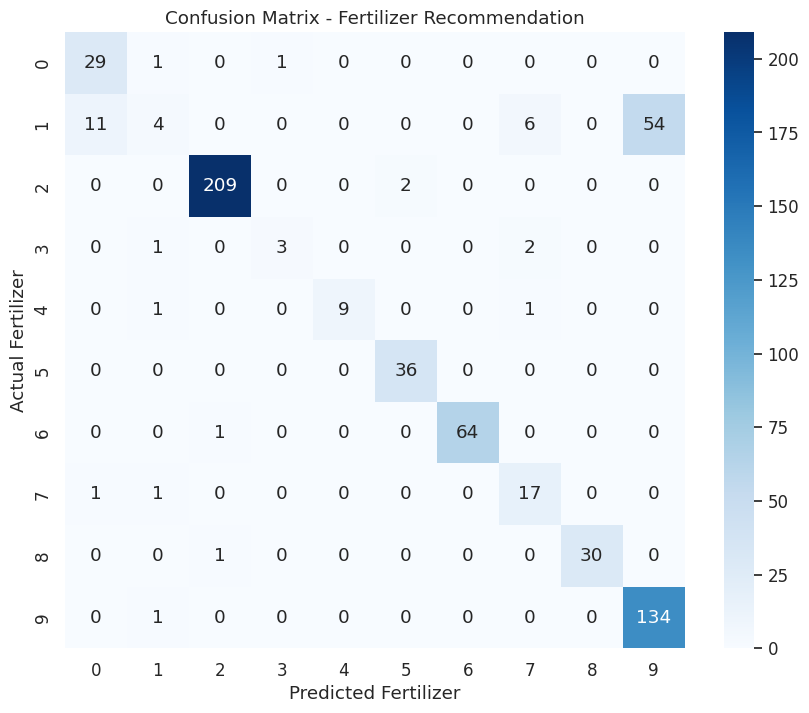

In [ ]:
# 1. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred, labels=stack_clf.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=stack_clf.classes_, yticklabels=stack_clf.classes_)
plt.title("Confusion Matrix - Fertilizer Recommendation")
plt.xlabel("Predicted Fertilizer")
plt.ylabel("Actual Fertilizer")
plt.show()

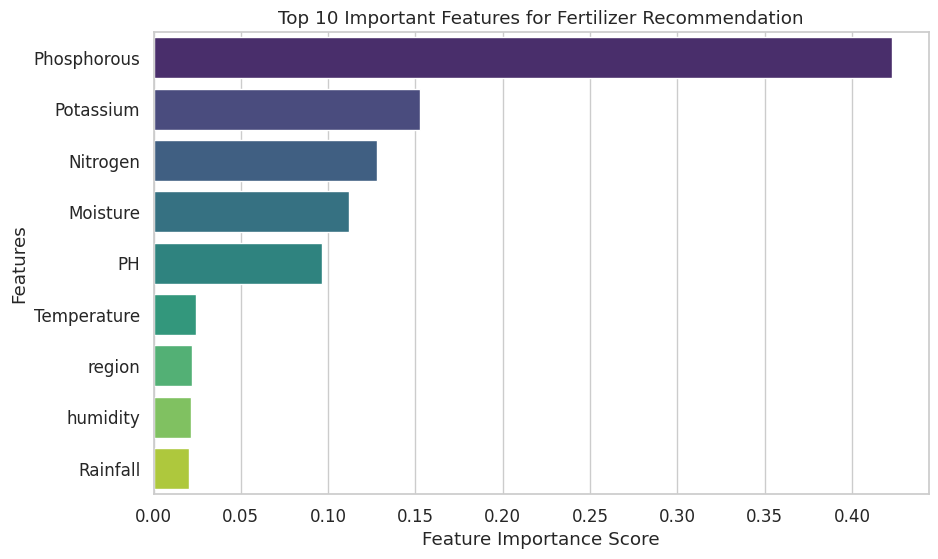

In [ ]:
# 2. Feature Importance Visualization (from a tree-based model like XGBoost)
# Using the XGBoost base model for interpretability
xgb_model = [model for name, model in base_models if name == "xgb"][0]
xgb_model.fit(X_train, y_train)

importances = xgb_model.feature_importances_
feat_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values[:10], y=feat_importance.index[:10], palette="viridis")
plt.title("Top 10 Important Features for Fertilizer Recommendation")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.show()

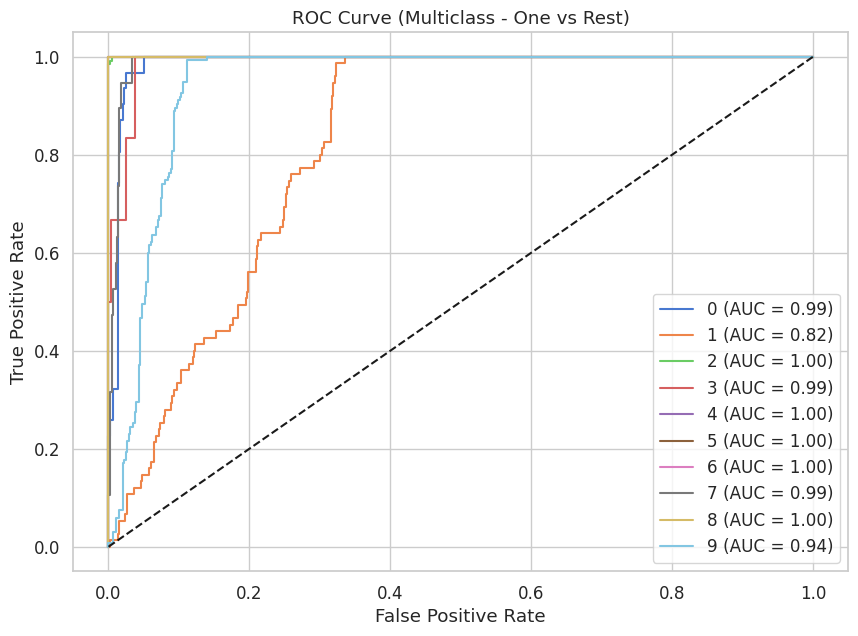

In [ ]:
#ROC Curve (One-vs-Rest for Multiclass)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Binarizing labels
y_test_bin = label_binarize(y_test, classes=stack_clf.classes_)
y_score = stack_clf.predict_proba(X_test)

# Plotting ROC for each class
plt.figure(figsize=(10,7))
for i, class_name in enumerate(stack_clf.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass - One vs Rest)")
plt.legend()
plt.show()


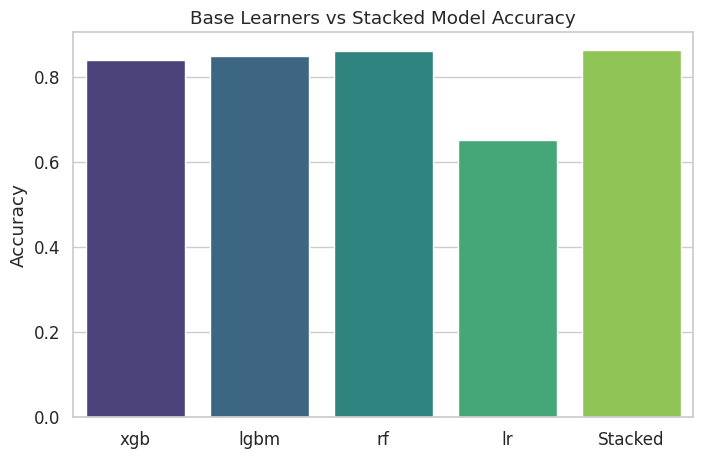

In [ ]:
#Comparison of Base Learner Accuracies
results = {}
for name, model in base_models:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = accuracy_score(y_test, preds)

# Add stacking model accuracy
results["Stacked"] = accuracy_score(y_test, y_pred)

plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.ylabel("Accuracy")
plt.title("Base Learners vs Stacked Model Accuracy")
plt.show()